In [1]:
import os
# Read WANDB API key from external file
with open("../wandb_api_key.txt", "r") as f:
    os.environ["WANDB_API_KEY"] = f.read().strip()
    print(os.environ["WANDB_API_KEY"])

26abb11684a03fc09307300eba9bc9cd3c71e4f0


In [16]:
import jax
import jax.numpy as jnp
def compute_tcn_receptive_field(K, D, L):
    """
    Computes the receptive field of a Temporal Convolutional Network (TCN).

    Args:
        K (list or array): Kernel size for each layer (length l).
        D (list or array): Dilation for each layer (length L).
        L (int): Number of layers.

    Returns:
        int: The receptive field size.
    """
    receptive_field = 1
    for i in range(L):
        receptive_field += (K[i] - 1) * D[i]
    return receptive_field

In [3]:
L = 6
K, D = [4]*L, [1]*6
rf = compute_tcn_receptive_field(K, D, L)
print(f"Receptive field for TCN with K={K}, D={D}, L={L}: {rf}")

Receptive field for TCN with K=[4, 4, 4, 4, 4, 4], D=[1, 1, 1, 1, 1, 1], L=6: 19


In [4]:
K, D = [4]*L, [2]*6
rf = compute_tcn_receptive_field(K, D, L)
print(f"Receptive field for TCN with K={K}, D={D}, L={L}: {rf}")


Receptive field for TCN with K=[4, 4, 4, 4, 4, 4], D=[2, 2, 2, 2, 2, 2], L=6: 37


In [47]:
import numpy as np

L = 9
K_values = [2**i for i in range(1, 8)]  # [2, 4, 8, 16, 32, 64, 128]
D_values = [2**i for i in range(0, 7)]  # [1, 2, 4, 8, 16, 32, 64]

grid = np.zeros((len(K_values), len(D_values)), dtype=int)

for i, K_val in enumerate(K_values):
    for j, D_val in enumerate(D_values):
        K = [K_val] * L
        D = [D_val] * L
        grid[i, j] = compute_tcn_receptive_field(K, D, L)

print(grid)


[[   10    19    37    73   145   289   577]
 [   28    55   109   217   433   865  1729]
 [   64   127   253   505  1009  2017  4033]
 [  136   271   541  1081  2161  4321  8641]
 [  280   559  1117  2233  4465  8929 17857]
 [  568  1135  2269  4537  9073 18145 36289]
 [ 1144  2287  4573  9145 18289 36577 73153]]


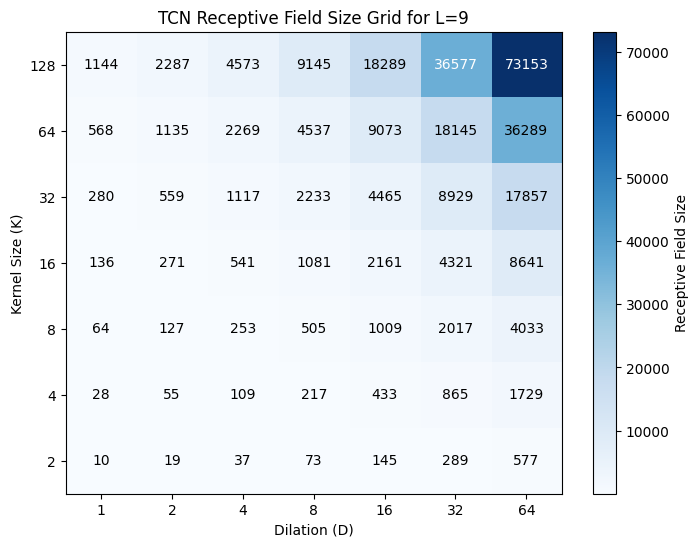

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
im = plt.imshow(grid, cmap='Blues', origin='lower', aspect='auto')

# Add text annotations
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        plt.text(j, i, str(grid[i, j]), ha='center', va='center', color='white' if grid[i, j] > grid.max()/2 else 'black')

plt.colorbar(im, label=f'Receptive Field Size')
plt.xticks(ticks=range(len(D_values)), labels=D_values)
plt.yticks(ticks=range(len(K_values)), labels=K_values)
plt.xlabel('Dilation (D)')
plt.ylabel('Kernel Size (K)')
plt.title(f'TCN Receptive Field Size Grid for L={L}')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

import numpy as np

K_values = [2**i for i in range(1, 8)]  # [2, 4, 8, 16, 32, 64, 128]
D_values = [2**i for i in range(0, 7)]  # [1, 2, 4, 8, 16, 32, 64]

for l in range(2, 10):
    grid = np.zeros((len(K_values), len(D_values)), dtype=int)
    for i, K_val in enumerate(K_values):
        for j, D_val in enumerate(D_values):
            K = [K_val] * l
            D = [D_val] * l
            grid[i, j] = compute_tcn_receptive_field(K, D, l)

    plt.figure(figsize=(8, 6))
    im = plt.imshow(grid, cmap='Blues', origin='lower', aspect='auto')

    # Add text annotations
    for i in range(grid.shape[0]):
        n_params = compute_n_params(H, K_values[i], l)
        for j in range(grid.shape[1]):
            plt.text(j, i, str(grid[i, j]) + f'\n({n_params})', ha='center', va='center', color='white' if grid[i, j] > grid.max()/2 else 'black')

    plt.colorbar(im, label=f'Receptive Field Size')
    plt.xticks(ticks=range(len(D_values)), labels=D_values)
    plt.yticks(ticks=range(len(K_values)), labels=K_values)
    plt.xlabel('Dilation (D)')
    plt.ylabel('Kernel Size (K)')
    plt.title(f'TCN Receptive Field Size Grid for L={l} (params)')
    plt.show()

In [23]:
import numpy as np

L = 6
K_values = [2**i for i in range(1, 8)]  # [4, 8, 16, 32, 64, 128]
D_values = [2**i for i in range(0, 5)]  # [1, 2, 4, 8, 16, 32, 64]

grid = np.zeros((len(K_values), len(D_values)), dtype=int)

for i, K_val in enumerate(K_values):
    for j, D_val in enumerate(D_values):
        print(f'{K_val=}, {D_val=}')
        K = [K_val] * L
        D = [D_val*2**i for i in range(L)]
        D_masked = [d if (K_val-1)*d <= 512 else 0 for d in D]  # Mask dilation values greater than 512
        D_max = max(D_masked)
        # print(D_masked, D_max)
        D = [d if d <= D_max else D_max for d in D]  # Ensure all dilations are within the max
        grid[i, j] = compute_tcn_receptive_field(K, D, L)
    print(f'\n')

print(grid)


K_val=2, D_val=1
K_val=2, D_val=2
K_val=2, D_val=4
K_val=2, D_val=8
K_val=2, D_val=16


K_val=4, D_val=1
K_val=4, D_val=2
K_val=4, D_val=4
K_val=4, D_val=8
K_val=4, D_val=16


K_val=8, D_val=1
K_val=8, D_val=2
K_val=8, D_val=4
K_val=8, D_val=8
K_val=8, D_val=16


K_val=16, D_val=1
K_val=16, D_val=2
K_val=16, D_val=4
K_val=16, D_val=8
K_val=16, D_val=16


K_val=32, D_val=1
K_val=32, D_val=2
K_val=32, D_val=4
K_val=32, D_val=8
K_val=32, D_val=16


K_val=64, D_val=1
K_val=64, D_val=2
K_val=64, D_val=4
K_val=64, D_val=8
K_val=64, D_val=16


K_val=128, D_val=1
K_val=128, D_val=2
K_val=128, D_val=4
K_val=128, D_val=8
K_val=128, D_val=16


[[  64  127  253  505 1009]
 [ 190  379  757 1129 1489]
 [ 442  883 1317 1737 2129]
 [ 946 1411 1861 2281 2641]
 [1458 1923 2357 2729 2977]
 [1954 2395 2773 3025    1]
 [2414 2795 3049    1    1]]


In [24]:
def compute_n_params(H, K, L):
    encoder = H
    decoder = H * 10
    conv = K * H
    mlp = 4*H**2 # w_up H x 2H and w_down 2H x H 
    block = mlp + conv
    total = encoder + decoder + block * L
    return total

H=32
K=4
L=6
n_params = compute_n_params(H, K, L)
print(f"Number of parameters for H={H}, K={K}, L={L}: {n_params}")

Number of parameters for H=32, K=4, L=6: 25696


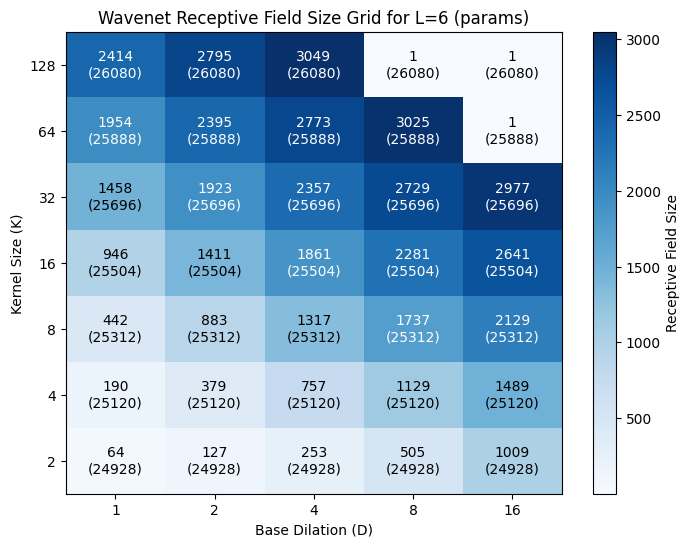

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
im = plt.imshow(grid, cmap='Blues', origin='lower', aspect='auto')

# Add text annotations
for i in range(grid.shape[0]):
    n_params = compute_n_params(H, i, L)
    for j in range(grid.shape[1]):
        plt.text(j, i, str(grid[i, j]) + f'\n({n_params})', ha='center', va='center', color='white' if grid[i, j] > grid.max()/2 else 'black')

plt.colorbar(im, label=f'Receptive Field Size')
plt.xticks(ticks=range(len(D_values)), labels=D_values)
plt.yticks(ticks=range(len(K_values)), labels=K_values)
plt.xlabel('Base Dilation (D)')
plt.ylabel('Kernel Size (K)')
plt.title(f'Wavenet Receptive Field Size Grid for L={L} (params)')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

import numpy as np

K_values = [2**i for i in range(1, 8)]  # [4, 8, 16, 32, 64, 128]
D_values = [2**i for i in range(0, 5)]  # [1, 2, 4, 8, 16, 32, 64]

for l in range(2, 10):
    H = 32  # Hidden size

    grid = np.zeros((len(K_values), len(D_values)), dtype=int)

    for i, K_val in enumerate(K_values):
        for j, D_val in enumerate(D_values):
            K = [K_val] * l
            D = [D_val*2**i for i in range(l)]
            grid[i, j] = compute_tcn_receptive_field(K, D, l)


    plt.figure(figsize=(8, 6))
    im = plt.imshow(grid, cmap='Blues', origin='lower', aspect='auto')

    # Add text annotations
    for i in range(grid.shape[0]):
        n_params = compute_n_params(H, K_values[i], l)
        for j in range(grid.shape[1]):
            plt.text(j, i, str(grid[i, j]) + f'\n({n_params})', ha='center', va='center', color='white' if grid[i, j] > grid.max()/2 else 'black')

    plt.colorbar(im, label=f'Receptive Field Size')
    plt.xticks(ticks=range(len(D_values)), labels=D_values)
    plt.yticks(ticks=range(len(K_values)), labels=K_values)
    plt.xlabel('Base Dilation (D)')
    plt.ylabel('Kernel Size (K)')
    plt.title(f'Wavenet Receptive Field Size Grid for L={l} (params)')
    plt.show()

In [12]:
import jax
import jax.numpy as jnp
def compute_tcn_receptive_field(K, D, L, max_rfl=512):
    """
    Computes the receptive field of a Temporal Convolutional Network (TCN),
    limiting the dilation so that rf_l does not exceed 512. If rf_l > 512,
    use the last D[j] that produced rf_l <= 512.

    Args:
        K (list or array): Kernel size for each layer (length L).
        D (list or array): Dilation for each layer (length L).
        L (int): Number of layers.

    Returns:
        int: The receptive field size.
        list: List of receptive field increments per layer.
    """
    receptive_field = 1
    rfs = []
    last_valid_dilation = D[0]
    i_last_valid_dilation = 0
    for i in range(L):
        rf_l = (K[i] - 1) * D[i]
        if rf_l > max_rfl:
            rf_l = (K[i] - 1) * last_valid_dilation
        else:
            last_valid_dilation = D[i]
            i_last_valid_dilation = i
        rfs.append(rf_l)
        receptive_field += rf_l
    return receptive_field, rfs, i_last_valid_dilation

In [21]:
L=6
K=[32] * L

# LERF
D=[2] * L
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF
D = [2**i for i in range(L)]
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=1024
D = [2**i for i in range(L)]
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=1024)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=256
D = [2**i for i in range(L)]
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=256)
print(rf, ':', rfs, 'boundary:', boundary)


373 : [62, 62, 62, 62, 62, 62] boundary: 5
1458 : [31, 62, 124, 248, 496, 496] boundary: 4
1954 : [31, 62, 124, 248, 496, 992] boundary: 5
962 : [31, 62, 124, 248, 248, 248] boundary: 3


In [27]:
L=6
K=[32] * L
offset = 1

# LERF
D=[2] * L
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=256
K_all = [32] * 10
D = [2**i for i in range(10)]
rf, rfs, boundary = compute_tcn_receptive_field(K_all, D, 10, max_rfl=1000000)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=256
D = [2**(i+offset) for i in range(L)]
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=256)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=512
D = [2**(i+offset) for i in range(L)]
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=1024
D = [2**(i+offset) for i in range(L)]
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=1024)
print(rf, ':', rfs, 'boundary:', boundary)
D = [2**(i+offset) for i in range(L)]
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=1024)
print(rf, ':', rfs, 'boundary:', boundary)

373 : [62, 62, 62, 62, 62, 62] boundary: 5
31714 : [31, 62, 124, 248, 496, 992, 1984, 3968, 7936, 15872] boundary: 9
1179 : [62, 124, 248, 248, 248, 248] boundary: 2
1923 : [62, 124, 248, 496, 496, 496] boundary: 3
2915 : [62, 124, 248, 496, 992, 992] boundary: 4
2915 : [62, 124, 248, 496, 992, 992] boundary: 4


In [3]:
L=6
K=[4] * L
offset = 1

# LERF
D=[2] * L
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=256
K_all = [K[0]] * 10
D = [2**i for i in range(10)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K_all, D, 10, max_rfl=1000000)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**i for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**(i+1) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=512
D = [2**(i+2) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=1024
D = [2**(i+3) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
D = [2**(i+4) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)

37 : [6, 6, 6, 6, 6, 6] boundary: 5
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
3070 : [3, 6, 12, 24, 48, 96, 192, 384, 768, 1536] boundary: 9


[1, 2, 4, 8, 16, 32]
190 : [3, 6, 12, 24, 48, 96] boundary: 5


[2, 4, 8, 16, 32, 64]
379 : [6, 12, 24, 48, 96, 192] boundary: 5


[4, 8, 16, 32, 64, 128]
757 : [12, 24, 48, 96, 192, 384] boundary: 5


[8, 16, 32, 64, 128, 256]
1129 : [24, 48, 96, 192, 384, 384] boundary: 4


[16, 32, 64, 128, 256, 512]
1489 : [48, 96, 192, 384, 384, 384] boundary: 3


In [4]:
L=6
K=[8] * L
offset = 1

# LERF
D=[2] * L
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=256
K_all = [K[0]] * 10
D = [2**i for i in range(10)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K_all, D, 10, max_rfl=1000000)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**i for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**(i+1) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=512
D = [2**(i+2) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=1024
D = [2**(i+3) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
D = [2**(i+4) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)

85 : [14, 14, 14, 14, 14, 14] boundary: 5
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
7162 : [7, 14, 28, 56, 112, 224, 448, 896, 1792, 3584] boundary: 9


[1, 2, 4, 8, 16, 32]
442 : [7, 14, 28, 56, 112, 224] boundary: 5


[2, 4, 8, 16, 32, 64]
883 : [14, 28, 56, 112, 224, 448] boundary: 5


[4, 8, 16, 32, 64, 128]
1317 : [28, 56, 112, 224, 448, 448] boundary: 4


[8, 16, 32, 64, 128, 256]
1737 : [56, 112, 224, 448, 448, 448] boundary: 3


[16, 32, 64, 128, 256, 512]
2129 : [112, 224, 448, 448, 448, 448] boundary: 2


In [5]:
L=6
K=[16] * L
offset = 1

# LERF
D=[2] * L
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=256
K_all = [K[0]] * 10
D = [2**i for i in range(10)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K_all, D, 10, max_rfl=1000000)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**i for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**(i+1) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=512
D = [2**(i+2) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=1024
D = [2**(i+3) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')


D = [2**(i+4) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)


181 : [30, 30, 30, 30, 30, 30] boundary: 5
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
15346 : [15, 30, 60, 120, 240, 480, 960, 1920, 3840, 7680] boundary: 9


[1, 2, 4, 8, 16, 32]
946 : [15, 30, 60, 120, 240, 480] boundary: 5


[2, 4, 8, 16, 32, 64]
1411 : [30, 60, 120, 240, 480, 480] boundary: 4


[4, 8, 16, 32, 64, 128]
1861 : [60, 120, 240, 480, 480, 480] boundary: 3


[8, 16, 32, 64, 128, 256]
2281 : [120, 240, 480, 480, 480, 480] boundary: 2


[16, 32, 64, 128, 256, 512]
2641 : [240, 480, 480, 480, 480, 480] boundary: 1


In [13]:
L=6
K=[32] * L
offset = 1

# LERF
D=[2] * L
print(K, D, L)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=256
K_all = [K[0]] * 10
D = [2**i for i in range(10)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K_all, D, 10, max_rfl=1000000)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**i for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**(i+1) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=512
D = [2**(i+2) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=1024
D = [2**(i+3) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')


D = [2**(i+4) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)


[32, 32, 32, 32, 32, 32] [2, 2, 2, 2, 2, 2] 6
373 : [62, 62, 62, 62, 62, 62] boundary: 5
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
31714 : [31, 62, 124, 248, 496, 992, 1984, 3968, 7936, 15872] boundary: 9


[1, 2, 4, 8, 16, 32]
1458 : [31, 62, 124, 248, 496, 496] boundary: 4


[2, 4, 8, 16, 32, 64]
1923 : [62, 124, 248, 496, 496, 496] boundary: 3


[4, 8, 16, 32, 64, 128]
2357 : [124, 248, 496, 496, 496, 496] boundary: 2


[8, 16, 32, 64, 128, 256]
2729 : [248, 496, 496, 496, 496, 496] boundary: 1


[16, 32, 64, 128, 256, 512]
2977 : [496, 496, 496, 496, 496, 496] boundary: 0


In [14]:
L=6
K=[64] * L
offset = 1

# LERF
D=[2] * L
print(K, D, L)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L)
print(rf, ':', rfs, 'boundary:', boundary)
# EERF with max_rfl=256
K_all = [K[0]] * 10
D = [2**i for i in range(10)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K_all, D, 10, max_rfl=1000000)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**i for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=256
D = [2**(i+1) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=512
D = [2**(i+2) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')
# EERF with max_rfl=1024
D = [2**(i+3) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)
print('\n')


D = [2**(i+4) for i in range(L)]
print(D)
rf, rfs, boundary = compute_tcn_receptive_field(K, D, L, max_rfl=512)
print(rf, ':', rfs, 'boundary:', boundary)


[64, 64, 64, 64, 64, 64] [2, 2, 2, 2, 2, 2] 6
757 : [126, 126, 126, 126, 126, 126] boundary: 5
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
64450 : [63, 126, 252, 504, 1008, 2016, 4032, 8064, 16128, 32256] boundary: 9


[1, 2, 4, 8, 16, 32]
1954 : [63, 126, 252, 504, 504, 504] boundary: 3


[2, 4, 8, 16, 32, 64]
2395 : [126, 252, 504, 504, 504, 504] boundary: 2


[4, 8, 16, 32, 64, 128]
2773 : [252, 504, 504, 504, 504, 504] boundary: 1


[8, 16, 32, 64, 128, 256]
3025 : [504, 504, 504, 504, 504, 504] boundary: 0


[16, 32, 64, 128, 256, 512]
6049 : [1008, 1008, 1008, 1008, 1008, 1008] boundary: 0


In [ ]:
31, 62, 124, 248, 496, 992: 1458
62, 124, 248, 496, 992, 1984: 1954




In [ ]:
9 tu dois clip

i=8: 
9-1 vs 9

i=9:
8, vs 9




In [ ]:
4,0:8
4,1:7
4,2:6
4,3:5
4,4:4

8,0:7
8,1:6
8,2:5
8,3:4

16,0: 6
16,1: 5
16,2: 4


